# Trip EDA + Weather Merge Pipeline (V2)

This notebook is a fresh pipeline that:
1. Rebuilds trip EDA-cleaned station-hour aggregates from `data/citibike`
2. Applies EDA-style filters (missing end station/coords, ghost/admin keywords, low-activity stations)
3. Engineers temporal + lag features
4. Merges hourly weather from `data/weather/open-meteo-2023-2025.csv`
5. Writes final training CSV and EDA outputs


In [1]:
from __future__ import annotations

from collections import defaultdict
from dataclasses import dataclass
from pathlib import Path
import gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display


In [2]:
@dataclass(frozen=True)
class Paths:
    project_root: Path
    trip_root: Path
    weather_path: Path
    output_dir: Path
    work_dir: Path
    monthly_dir: Path
    temp_dir: Path
    eda_dir: Path
    output_path: Path
    coords_path: Path
    stations_removed_path: Path
    cleaning_summary_path: Path
    member_hourly_path: Path
    daytype_hourly_path: Path
    top_start_path: Path
    top_end_path: Path
    monthly_summary_path: Path
    corr_path: Path


PROJECT_ROOT = (Path.cwd().resolve().parent.parent if Path.cwd().resolve().name == 'data_preparation' else Path.cwd().resolve())
TARGET_YEARS = {2023, 2024, 2025}
RESET_OUTPUTS = False
CHUNK_SIZE = 250_000
LOW_ACTIVITY_THRESHOLD = 5
GHOST_KEYWORDS = ['test', 'workshop', 'maintenance', 'dot', 'charging', 'check', 'hub', 'warehouse']

year_label = f"{min(TARGET_YEARS)}_{max(TARGET_YEARS)}"
output_dir = PROJECT_ROOT / 'data' / 'proceed'
work_dir = output_dir / 'trip_weather_eda_v2_work'

paths = Paths(
    project_root=PROJECT_ROOT,
    trip_root=PROJECT_ROOT / 'data' / 'citibike',
    weather_path=PROJECT_ROOT / 'data' / 'weather' / 'open-meteo-2023-2025.csv',
    output_dir=output_dir,
    work_dir=work_dir,
    monthly_dir=work_dir / 'monthly_station_hour',
    temp_dir=work_dir / 'temp_agg',
    eda_dir=work_dir / 'eda',
    output_path=output_dir / f'micro_mobility_training_data_{year_label}_weather_v2.csv',
    coords_path=work_dir / 'coords_lookup.csv',
    stations_removed_path=work_dir / 'stations_removed.csv',
    cleaning_summary_path=work_dir / 'eda' / 'cleaning_summary.csv',
    member_hourly_path=work_dir / 'eda' / 'hourly_member_casual.csv',
    daytype_hourly_path=work_dir / 'eda' / 'hourly_weekday_weekend.csv',
    top_start_path=work_dir / 'eda' / 'top_start_stations.csv',
    top_end_path=work_dir / 'eda' / 'top_end_stations.csv',
    monthly_summary_path=work_dir / 'monthly_processing_summary.csv',
    corr_path=work_dir / 'eda' / 'feature_correlation.csv',
)

for d in [paths.output_dir, paths.work_dir, paths.monthly_dir, paths.temp_dir, paths.eda_dir]:
    d.mkdir(parents=True, exist_ok=True)

if RESET_OUTPUTS:
    for p in [
        paths.output_path, paths.coords_path, paths.stations_removed_path,
        paths.cleaning_summary_path, paths.member_hourly_path, paths.daytype_hourly_path,
        paths.top_start_path, paths.top_end_path, paths.monthly_summary_path, paths.corr_path,
    ]:
        if p.exists():
            p.unlink()
    for p in paths.monthly_dir.glob('*.csv'):
        p.unlink()
    for p in paths.temp_dir.glob('*.csv'):
        p.unlink()

paths


Paths(project_root=WindowsPath('D:/AIT/ML/project/citibike-netdemand-prediction'), trip_root=WindowsPath('D:/AIT/ML/project/citibike-netdemand-prediction/data/citibike'), weather_path=WindowsPath('D:/AIT/ML/project/citibike-netdemand-prediction/data/weather/open-meteo-2023-2025.csv'), output_dir=WindowsPath('D:/AIT/ML/project/citibike-netdemand-prediction/data/proceed'), work_dir=WindowsPath('D:/AIT/ML/project/citibike-netdemand-prediction/data/proceed/trip_weather_eda_v2_work'), monthly_dir=WindowsPath('D:/AIT/ML/project/citibike-netdemand-prediction/data/proceed/trip_weather_eda_v2_work/monthly_station_hour'), temp_dir=WindowsPath('D:/AIT/ML/project/citibike-netdemand-prediction/data/proceed/trip_weather_eda_v2_work/temp_agg'), eda_dir=WindowsPath('D:/AIT/ML/project/citibike-netdemand-prediction/data/proceed/trip_weather_eda_v2_work/eda'), output_path=WindowsPath('D:/AIT/ML/project/citibike-netdemand-prediction/data/proceed/micro_mobility_training_data_2023_2025_weather_v2.csv'), coo

In [3]:
def discover_trip_files(root: Path, years: set[int]) -> list[Path]:
    files = []
    for p in sorted(root.rglob('*.csv')):
        token = p.name[:6]
        if len(token) == 6 and token.isdigit() and int(token[:4]) in years:
            files.append(p)
    return files


def load_weather_df(weather_path: Path) -> pd.DataFrame:
    rename_map = {
        'temperature_2m (Â°C)': 'temp_2m',
        'temperature_2m (?C)': 'temp_2m',
        'temperature_2m (C)': 'temp_2m',
        'temperature_2m (°C)': 'temp_2m',
        'relative_humidity_2m (%)': 'rh_2m',
        'rain (mm)': 'rain_mm',
        'snowfall (cm)': 'snow_cm',
        'wind_speed_10m (km/h)': 'wind_kmh',
        'precipitation (mm)': 'precip_mm',
        'cloud_cover (%)': 'cloud_cover',
        'cloud_cover_low (%)': 'cloud_low',
        'cloud_cover_mid (%)': 'cloud_mid',
        'cloud_cover_high (%)': 'cloud_high',
    }
    w = pd.read_csv(weather_path, skiprows=3)
    w['datetime_hour'] = pd.to_datetime(w['time'], errors='coerce')
    w = w.dropna(subset=['datetime_hour']).rename(columns=rename_map)
    keep = ['datetime_hour', 'temp_2m', 'rh_2m', 'rain_mm', 'snow_cm', 'wind_kmh', 'precip_mm', 'cloud_cover', 'cloud_low', 'cloud_mid', 'cloud_high']
    return w[keep].sort_values('datetime_hour').reset_index(drop=True)


trip_files = discover_trip_files(paths.trip_root, TARGET_YEARS)
print('Trip files found:', len(trip_files))
print('First 3:', [p.name for p in trip_files[:3]])
if not trip_files:
    raise RuntimeError('No trip CSV files found for TARGET_YEARS.')


Trip files found: 143
First 3: ['202301-citibike-tripdata_1.csv', '202301-citibike-tripdata_2.csv', '202302-citibike-tripdata_1.csv']


In [4]:
# PASS 1: EDA-style station filtering prep
start_counts = pd.Series(dtype='int64')
ghost_mask_pattern = '|'.join(GHOST_KEYWORDS)
ghost_stations = set()

cleaning_counts = defaultdict(int)

for file_path in trip_files:
    for chunk in pd.read_csv(file_path, chunksize=CHUNK_SIZE):
        cleaning_counts['raw_rows'] += len(chunk)

        chunk['started_at'] = pd.to_datetime(chunk['started_at'], errors='coerce')
        chunk['ended_at'] = pd.to_datetime(chunk['ended_at'], errors='coerce')
        invalid_ts = chunk[['started_at', 'ended_at']].isna().any(axis=1)
        cleaning_counts['drop_invalid_timestamp'] += int(invalid_ts.sum())
        chunk = chunk.loc[~invalid_ts].copy()

        dur_min = (chunk['ended_at'] - chunk['started_at']).dt.total_seconds() / 60.0
        short_mask = dur_min < 1
        long_mask = dur_min > 1440
        cleaning_counts['drop_duration_lt_1m'] += int(short_mask.sum())
        cleaning_counts['drop_duration_gt_1440m'] += int(long_mask.sum())
        chunk = chunk.loc[~(short_mask | long_mask)].copy()

        missing_end = chunk[['end_station_name', 'end_lat', 'end_lng']].isna().any(axis=1)
        cleaning_counts['drop_missing_end_station_or_coords'] += int(missing_end.sum())
        chunk = chunk.loc[~missing_end].copy()

        if len(chunk) == 0:
            continue

        s = chunk['start_station_name'].value_counts()
        start_counts = start_counts.add(s, fill_value=0)

        s_ghost = chunk['start_station_name'].astype(str).str.contains(ghost_mask_pattern, case=False, na=False)
        e_ghost = chunk['end_station_name'].astype(str).str.contains(ghost_mask_pattern, case=False, na=False)
        ghost_stations.update(chunk.loc[s_ghost, 'start_station_name'].dropna().unique().tolist())
        ghost_stations.update(chunk.loc[e_ghost, 'end_station_name'].dropna().unique().tolist())

start_counts = start_counts.sort_values(ascending=False)
low_activity_stations = set(start_counts[start_counts < LOW_ACTIVITY_THRESHOLD].index.tolist())
stations_to_remove = set(ghost_stations).union(low_activity_stations)

removed_df = pd.DataFrame({'station': sorted(stations_to_remove)})
removed_df.to_csv(paths.stations_removed_path, index=False)

print('Ghost stations:', len(ghost_stations))
print('Low activity stations:', len(low_activity_stations))
print('Total stations_to_remove:', len(stations_to_remove))
print('Saved:', paths.stations_removed_path)


C:\Users\thett\AppData\Local\Temp\ipykernel_8244\3098528639.py:9: DtypeWarning: Columns (0: start_station_id, 1: end_station_id) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(file_path, chunksize=CHUNK_SIZE):
C:\Users\thett\AppData\Local\Temp\ipykernel_8244\3098528639.py:9: DtypeWarning: Columns (0: start_station_id) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(file_path, chunksize=CHUNK_SIZE):
C:\Users\thett\AppData\Local\Temp\ipykernel_8244\3098528639.py:9: DtypeWarning: Columns (0: start_station_id, 1: end_station_id) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(file_path, chunksize=CHUNK_SIZE):
C:\Users\thett\AppData\Local\Temp\ipykernel_8244\3098528639.py:9: DtypeWarning: Columns (0: start_station_id, 1: end_station_id) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_c

Ghost stations: 3
Low activity stations: 38
Total stations_to_remove: 40
Saved: D:\AIT\ML\project\citibike-netdemand-prediction\data\proceed\trip_weather_eda_v2_work\stations_removed.csv


C:\Users\thett\AppData\Local\Temp\ipykernel_8244\3098528639.py:9: DtypeWarning: Columns (0: end_station_id) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(file_path, chunksize=CHUNK_SIZE):


In [5]:
# PASS 2: aggregate cleaned flows + EDA outputs
member_hour_counter = defaultdict(int)
daytype_hour_counter = defaultdict(int)
top_start_counter = defaultdict(int)
top_end_counter = defaultdict(int)
month_rows_counter = defaultdict(int)

coord_sum_lat = defaultdict(float)
coord_sum_lng = defaultdict(float)
coord_count = defaultdict(int)

def append_temp(df: pd.DataFrame, path: Path):
    if len(df) == 0:
        return
    header = not path.exists()
    df.to_csv(path, mode='a', header=header, index=False)


for file_path in trip_files:
    for chunk in pd.read_csv(file_path, chunksize=CHUNK_SIZE):
        chunk['started_at'] = pd.to_datetime(chunk['started_at'], errors='coerce')
        chunk['ended_at'] = pd.to_datetime(chunk['ended_at'], errors='coerce')
        chunk = chunk.loc[~chunk[['started_at', 'ended_at']].isna().any(axis=1)].copy()

        dur_min = (chunk['ended_at'] - chunk['started_at']).dt.total_seconds() / 60.0
        chunk = chunk.loc[(dur_min >= 1) & (dur_min <= 1440)].copy()
        chunk = chunk.loc[~chunk[['end_station_name', 'end_lat', 'end_lng']].isna().any(axis=1)].copy()

        if len(chunk) == 0:
            continue

        remove_mask = chunk['start_station_name'].isin(stations_to_remove) | chunk['end_station_name'].isin(stations_to_remove)
        chunk = chunk.loc[~remove_mask].copy()
        if len(chunk) == 0:
            continue

        chunk['hour'] = chunk['started_at'].dt.hour.astype('int8')
        chunk['day_of_week'] = chunk['started_at'].dt.dayofweek.astype('int8')
        chunk['day_type'] = np.where(chunk['day_of_week'] >= 5, 'weekend', 'weekday')
        chunk['start_hour_ts'] = chunk['started_at'].dt.floor('h')
        chunk['end_hour_ts'] = chunk['ended_at'].dt.floor('h')

        mh = chunk.groupby(['hour', 'member_casual']).size()
        for idx, val in mh.items():
            member_hour_counter[idx] += int(val)

        dh = chunk.groupby(['hour', 'day_type']).size()
        for idx, val in dh.items():
            daytype_hour_counter[idx] += int(val)

        ss = chunk['start_station_name'].value_counts()
        for k, v in ss.items():
            top_start_counter[k] += int(v)

        es = chunk['end_station_name'].value_counts()
        for k, v in es.items():
            top_end_counter[k] += int(v)

        # Coordinates from both start/end
        for sc, lat, lng in chunk[['start_station_name', 'start_lat', 'start_lng']].dropna().itertuples(index=False):
            coord_sum_lat[sc] += float(lat)
            coord_sum_lng[sc] += float(lng)
            coord_count[sc] += 1
        for sc, lat, lng in chunk[['end_station_name', 'end_lat', 'end_lng']].dropna().itertuples(index=False):
            coord_sum_lat[sc] += float(lat)
            coord_sum_lng[sc] += float(lng)
            coord_count[sc] += 1

        dep = chunk.groupby(['start_station_name', 'start_hour_ts']).size().reset_index(name='outflow')
        dep = dep.rename(columns={'start_station_name': 'station', 'start_hour_ts': 'datetime_hour'})
        dep['month_key'] = dep['datetime_hour'].dt.strftime('%Y%m')

        arr = chunk.groupby(['end_station_name', 'end_hour_ts']).size().reset_index(name='inflow')
        arr = arr.rename(columns={'end_station_name': 'station', 'end_hour_ts': 'datetime_hour'})
        arr['month_key'] = arr['datetime_hour'].dt.strftime('%Y%m')

        for month_key, g in dep.groupby('month_key'):
            append_temp(g[['station', 'datetime_hour', 'outflow']], paths.temp_dir / f'dep_{month_key}.csv')

        for month_key, g in arr.groupby('month_key'):
            append_temp(g[['station', 'datetime_hour', 'inflow']], paths.temp_dir / f'arr_{month_key}.csv')

        del chunk, dep, arr
        gc.collect()

print('Pass 2 done. Temp files:', len(list(paths.temp_dir.glob('*.csv'))))


C:\Users\thett\AppData\Local\Temp\ipykernel_8244\3299238397.py:20: DtypeWarning: Columns (0: start_station_id, 1: end_station_id) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(file_path, chunksize=CHUNK_SIZE):
C:\Users\thett\AppData\Local\Temp\ipykernel_8244\3299238397.py:20: DtypeWarning: Columns (0: start_station_id) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(file_path, chunksize=CHUNK_SIZE):
C:\Users\thett\AppData\Local\Temp\ipykernel_8244\3299238397.py:20: DtypeWarning: Columns (0: start_station_id, 1: end_station_id) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.read_csv(file_path, chunksize=CHUNK_SIZE):
C:\Users\thett\AppData\Local\Temp\ipykernel_8244\3299238397.py:20: DtypeWarning: Columns (0: start_station_id, 1: end_station_id) have mixed types. Specify dtype option on import or set low_memory=False.
  for chunk in pd.re

Pass 2 done. Temp files: 73


In [6]:
# Finalize monthly net files + save EDA outputs
def reduce_monthly(file_path: Path, value_col: str) -> pd.Series:
    acc = None
    for ch in pd.read_csv(file_path, parse_dates=['datetime_hour'], chunksize=CHUNK_SIZE):
        g = ch.groupby(['station', 'datetime_hour'])[value_col].sum()
        acc = g if acc is None else acc.add(g, fill_value=0)
    if acc is None:
        return pd.Series(dtype='float64')
    acc.index = acc.index.set_names(['station', 'datetime_hour'])
    return acc


month_keys = sorted({p.stem.split('_', 1)[1] for p in paths.temp_dir.glob('dep_*.csv')}.union({p.stem.split('_', 1)[1] for p in paths.temp_dir.glob('arr_*.csv')}))

monthly_rows = []
for mk in month_keys:
    dep_path = paths.temp_dir / f'dep_{mk}.csv'
    arr_path = paths.temp_dir / f'arr_{mk}.csv'

    empty_idx = pd.MultiIndex.from_arrays([[], []], names=['station', 'datetime_hour'])
    dep_s = reduce_monthly(dep_path, 'outflow') if dep_path.exists() else pd.Series(index=empty_idx, dtype='float64')
    arr_s = reduce_monthly(arr_path, 'inflow') if arr_path.exists() else pd.Series(index=empty_idx, dtype='float64')

    if dep_s.index.nlevels == 2:
        dep_s.index = dep_s.index.set_names(['station', 'datetime_hour'])
    if arr_s.index.nlevels == 2:
        arr_s.index = arr_s.index.set_names(['station', 'datetime_hour'])

    monthly = pd.concat([dep_s.rename('outflow'), arr_s.rename('inflow')], axis=1).fillna(0).reset_index()
    monthly['net_demand'] = monthly['inflow'] - monthly['outflow']
    monthly = monthly[['station', 'datetime_hour', 'outflow', 'inflow', 'net_demand']]
    monthly = monthly.sort_values(['station', 'datetime_hour']).reset_index(drop=True)

    out_path = paths.monthly_dir / f'station_hour_net_flow_{mk}.csv'
    monthly.to_csv(out_path, index=False)
    monthly_rows.append({'month_key': mk, 'rows': len(monthly)})

monthly_summary = pd.DataFrame(monthly_rows).sort_values('month_key')
monthly_summary.to_csv(paths.monthly_summary_path, index=False)

coords_df = pd.DataFrame({
    'station': list(coord_count.keys()),
    'lat': [coord_sum_lat[s] / coord_count[s] for s in coord_count],
    'lng': [coord_sum_lng[s] / coord_count[s] for s in coord_count],
}).sort_values('station').reset_index(drop=True)
coords_df.to_csv(paths.coords_path, index=False)

member_hourly = pd.DataFrame([{'hour': h, 'member_casual': mc, 'trip_count': c} for (h, mc), c in member_hour_counter.items()]).sort_values(['hour', 'member_casual'])
daytype_hourly = pd.DataFrame([{'hour': h, 'day_type': dt, 'trip_count': c} for (h, dt), c in daytype_hour_counter.items()]).sort_values(['hour', 'day_type'])
top_start = pd.DataFrame({'station': list(top_start_counter.keys()), 'trip_count': list(top_start_counter.values())}).sort_values('trip_count', ascending=False)
top_end = pd.DataFrame({'station': list(top_end_counter.keys()), 'trip_count': list(top_end_counter.values())}).sort_values('trip_count', ascending=False)

member_hourly.to_csv(paths.member_hourly_path, index=False)
daytype_hourly.to_csv(paths.daytype_hourly_path, index=False)
top_start.to_csv(paths.top_start_path, index=False)
top_end.to_csv(paths.top_end_path, index=False)

cleaning_summary = pd.DataFrame({'metric': list(cleaning_counts.keys()), 'value': list(cleaning_counts.values())})
cleaning_summary.to_csv(paths.cleaning_summary_path, index=False)

print('Monthly files:', len(list(paths.monthly_dir.glob('station_hour_net_flow_*.csv'))))
display(monthly_summary.head())
display(top_start.head(10))


Monthly files: 37


,month_key,rows
0,202212,137
1,202301,682492
2,202302,634450
3,202303,732168
4,202304,783379


,station,trip_count
0,W 21 St & 6 Ave,469098
2,West St & Chambers St,385131
17,Broadway & W 58 St,380735
3,University Pl & E 14 St,376441
6,W 31 St & 7 Ave,368418
25,11 Ave & W 41 St,362754
42,Lafayette St & E 8 St,357530
9,Broadway & E 14 St,353635
4,Broadway & W 25 St,341144
37,8 Ave & W 31 St,339834


In [7]:
# Build final engineered + weather merged dataset
weather_df = load_weather_df(paths.weather_path).set_index('datetime_hour')
coords = pd.read_csv(paths.coords_path)
stations = coords['station'].to_numpy()
lat_values = coords['lat'].to_numpy(dtype=np.float32)
lng_values = coords['lng'].to_numpy(dtype=np.float32)
station_to_idx = {s: i for i, s in enumerate(stations)}

if paths.output_path.exists():
    paths.output_path.unlink()

write_header = True
history = np.zeros((24, len(stations)), dtype=np.float32)

for mpath in sorted(paths.monthly_dir.glob('station_hour_net_flow_*.csv')):
    mk = mpath.stem.rsplit('_', 1)[-1]
    month_start = pd.Timestamp(year=int(mk[:4]), month=int(mk[4:]), day=1, hour=0)
    next_month = month_start + pd.offsets.MonthBegin(1)
    hour_index = pd.date_range(start=month_start, end=next_month - pd.Timedelta(hours=1), freq='h')

    month_df = pd.read_csv(mpath, parse_dates=['datetime_hour'])
    month_df = month_df[month_df['station'].isin(station_to_idx)]
    month_df['station_idx'] = month_df['station'].map(station_to_idx).astype('int32')

    pivot = month_df.pivot(index='datetime_hour', columns='station_idx', values='net_demand').reindex(hour_index).fillna(0.0)
    month_matrix = np.zeros((len(hour_index), len(stations)), dtype=np.float32)
    month_matrix[:, pivot.columns.to_numpy()] = pivot.to_numpy(dtype=np.float32)

    ext = np.vstack([history, month_matrix])
    lag_1 = ext[23:-1]
    lag_2 = ext[22:-2]
    lag_3 = ext[21:-3]
    lag_24 = ext[:-24]
    roll3 = (lag_1 + lag_2 + lag_3) / 3.0

    w = weather_df.reindex(hour_index).copy()
    w['is_raining'] = (w['precip_mm'].fillna(0) > 0).astype('int8')
    w['is_snowing'] = (w['snow_cm'].fillna(0) > 0).astype('int8')

    date_values = hour_index.normalize().to_numpy()
    dt_values = hour_index.to_numpy()
    hour_vals = hour_index.hour.to_numpy(dtype=np.int8)
    dow_vals = hour_index.dayofweek.to_numpy(dtype=np.int8)
    weekend_vals = (dow_vals >= 5).astype(np.int8)
    hour_sin = np.sin(2 * np.pi * hour_vals / 24).astype(np.float32)
    hour_cos = np.cos(2 * np.pi * hour_vals / 24).astype(np.float32)
    day_sin = np.sin(2 * np.pi * dow_vals / 7).astype(np.float32)
    day_cos = np.cos(2 * np.pi * dow_vals / 7).astype(np.float32)

    weather_cols = ['temp_2m', 'rh_2m', 'rain_mm', 'snow_cm', 'wind_kmh', 'precip_mm', 'cloud_cover', 'cloud_low', 'cloud_mid', 'cloud_high', 'is_raining', 'is_snowing']
    weather_arrays = {c: w[c].to_numpy() for c in weather_cols}

    batch_df = pd.DataFrame({
        'station': np.repeat(stations, len(hour_index)),
        'date': np.tile(date_values, len(stations)),
        'hour': np.tile(hour_vals, len(stations)),
        'datetime_hour': np.tile(dt_values, len(stations)),
        'is_weekend': np.tile(weekend_vals, len(stations)),
        'net_demand': month_matrix.T.reshape(-1),
        'lat': np.repeat(lat_values, len(hour_index)),
        'lng': np.repeat(lng_values, len(hour_index)),
        'hour_sin': np.tile(hour_sin, len(stations)),
        'hour_cos': np.tile(hour_cos, len(stations)),
        'day_of_week': np.tile(dow_vals, len(stations)),
        'day_sin': np.tile(day_sin, len(stations)),
        'day_cos': np.tile(day_cos, len(stations)),
        'lag_1h': lag_1.T.reshape(-1),
        'lag_2h': lag_2.T.reshape(-1),
        'lag_3h': lag_3.T.reshape(-1),
        'lag_24h': lag_24.T.reshape(-1),
        'rolling_mean_3h': roll3.T.reshape(-1),
    })

    for c, vals in weather_arrays.items():
        batch_df[c] = np.tile(vals, len(stations))

    batch_df.to_csv(paths.output_path, mode='a', header=write_header, index=False)
    write_header = False

    history = ext[-24:].copy()
    del month_df, pivot, month_matrix, ext, lag_1, lag_2, lag_3, lag_24, roll3, batch_df
    gc.collect()

print('Final output written:', paths.output_path)
print('Size (MB):', round(paths.output_path.stat().st_size / 1024 / 1024, 2))


Final output written: D:\AIT\ML\project\citibike-netdemand-prediction\data\proceed\micro_mobility_training_data_2023_2025_weather_v2.csv
Size (MB): 11746.02


In [8]:
# Quick validation + sample (fast)
head_df = pd.read_csv(paths.output_path, nrows=5)

# Fast tail sample via chunks (no full line count)
tail_chunk = None
for ch in pd.read_csv(paths.output_path, chunksize=200_000):
    tail_chunk = ch
tail_df = tail_chunk.tail(5)

print('Columns:', len(head_df.columns))
display(head_df)
display(tail_df)



Columns: 30


,station,date,hour,datetime_hour,is_weekend,net_demand,lat,lng,hour_sin,hour_cos,...,rain_mm,snow_cm,wind_kmh,precip_mm,cloud_cover,cloud_low,cloud_mid,cloud_high,is_raining,is_snowing
0,1 Ave & E 110 St,2022-12-01,0,2022-12-01 00:00:00,0,0.0,40.792328,-73.9383,0.000000,1.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
1,1 Ave & E 110 St,2022-12-01,1,2022-12-01 01:00:00,0,0.0,40.792328,-73.9383,0.258819,0.965926,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
2,1 Ave & E 110 St,2022-12-01,2,2022-12-01 02:00:00,0,0.0,40.792328,-73.9383,0.500000,0.866025,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
3,1 Ave & E 110 St,2022-12-01,3,2022-12-01 03:00:00,0,0.0,40.792328,-73.9383,0.707107,0.707107,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0
4,1 Ave & E 110 St,2022-12-01,4,2022-12-01 04:00:00,0,0.0,40.792328,-73.9383,0.866025,0.500000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0


,station,date,hour,datetime_hour,is_weekend,net_demand,lat,lng,hour_sin,hour_cos,...,rain_mm,snow_cm,wind_kmh,precip_mm,cloud_cover,cloud_low,cloud_mid,cloud_high,is_raining,is_snowing
66456931,Yankee Ferry Terminal,2025-12-31,19,2025-12-31 19:00:00,0,0.0,40.687065,-74.016754,-0.965926,0.258819,...,0.0,0.0,4.8,0.0,98,51,91,88,0,0
66456932,Yankee Ferry Terminal,2025-12-31,20,2025-12-31 20:00:00,0,0.0,40.687065,-74.016754,-0.866025,0.500000,...,0.0,0.0,4.9,0.0,98,19,87,96,0,0
66456933,Yankee Ferry Terminal,2025-12-31,21,2025-12-31 21:00:00,0,0.0,40.687065,-74.016754,-0.707107,0.707107,...,0.0,0.0,2.5,0.0,99,51,80,98,0,0
66456934,Yankee Ferry Terminal,2025-12-31,22,2025-12-31 22:00:00,0,0.0,40.687065,-74.016754,-0.500000,0.866025,...,0.0,0.0,2.6,0.0,98,9,84,96,0,0
66456935,Yankee Ferry Terminal,2025-12-31,23,2025-12-31 23:00:00,0,0.0,40.687065,-74.016754,-0.258819,0.965926,...,0.0,0.0,2.0,0.0,99,8,93,98,0,0


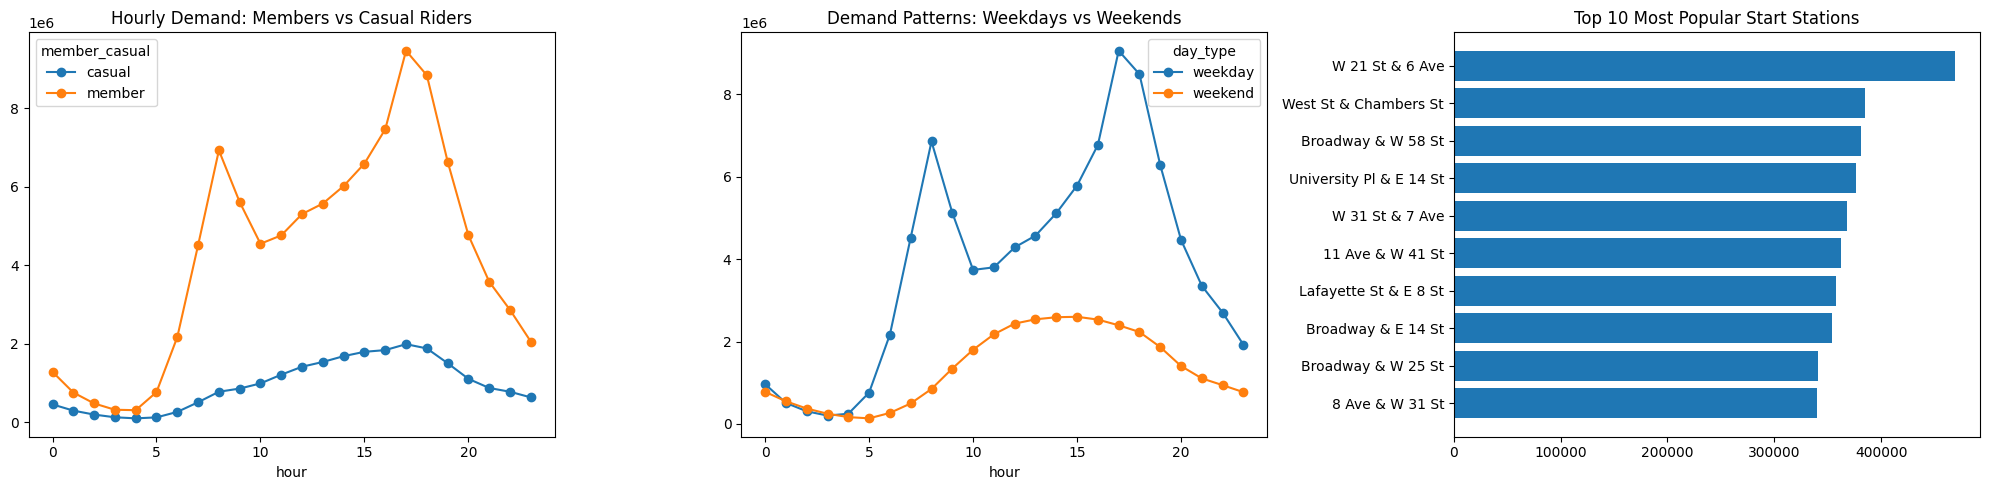

In [9]:

# EDA charts
member_hourly = pd.read_csv(paths.member_hourly_path)
daytype_hourly = pd.read_csv(paths.daytype_hourly_path)
top_start = pd.read_csv(paths.top_start_path).head(10).sort_values('trip_count')

fig, axes = plt.subplots(1, 3, figsize=(20, 5))
member_pivot = member_hourly.pivot(index='hour', columns='member_casual', values='trip_count').fillna(0).sort_index()
daytype_pivot = daytype_hourly.pivot(index='hour', columns='day_type', values='trip_count').fillna(0).sort_index()
member_pivot.plot(ax=axes[0], marker='o')
axes[0].set_title('Hourly Demand: Members vs Casual Riders')
daytype_pivot.plot(ax=axes[1], marker='o')
axes[1].set_title('Demand Patterns: Weekdays vs Weekends')
axes[2].barh(top_start['station'], top_start['trip_count'])
axes[2].set_title('Top 10 Most Popular Start Stations')
plt.tight_layout()
plt.show()